# Homework: Logistic Regression

$
\newcommand{\xv}{\mathbf{x}}
\newcommand{\wv}{\mathbf{w}}
\newcommand{\yv}{\mathbf{y}}
\newcommand{\tv}{\mathbf{t}}
\newcommand{\zv}{\mathbf{z}}
\newcommand{\uv}{\mathbf{u}}
\newcommand{\vv}{\mathbf{v}}
\newcommand{\bv}{\mathbf{b}}
\newcommand{\av}{\mathbf{a}}
\newcommand{\hv}{\mathbf{h}}
\newcommand{\onev}{\mathbf{1}}
\newcommand{\zerov}{\mathbf{0}}
\newcommand{\Chi}{\mathcal{X}}
\newcommand{\R}{\rm I\!R}
\newcommand{\sign}{\text{sign}}
\newcommand{\Ym}{\mathbf{Y}}
\newcommand{\Tm}{\mathbf{T}}
\newcommand{\Xm}{\mathbf{X}}
\newcommand{\Wm}{\mathbf{W}}
\newcommand{\Zm}{\mathbf{Z}}
\newcommand{\Um}{\mathbf{U}}
\newcommand{\Vm}{\mathbf{V}}
\newcommand{\Am}{\mathbf{A}}
\newcommand{\Hm}{\mathbf{H}}
\newcommand{\Idm}{\mathbf{I}}
\newcommand{\muv}{\boldsymbol\mu}
\newcommand{\Sigmav}{\boldsymbol\Sigma}
\newcommand{\Lambdav}{\boldsymbol\Lambda}
\newcommand{\xspace}{\mathcal{X}}
\newcommand{\yspace}{\mathcal{Y}}
\newcommand{\ind}{\perp\!\!\!\!\!\perp}
$

## Name: <span style="color:blue"> *Shashank PB* </span>

## Utils

In [2]:
from typing import List, Dict, Tuple, Callable
import os
import gc
import traceback
import warnings
from pdb import set_trace

import sklearn
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

np.set_printoptions(suppress=True)

In [3]:
class TodoCheckFailed(Exception):
    pass

def todo_check(asserts, mute=False, success_msg="", **kwargs):
    locals().update(kwargs)
    failed_err = "You passed {}/{} and FAILED the following code checks:\n{}"
    failed = ""
    n_failed = 0
    for check, (condi, err) in enumerate(asserts):
        exc_failed = False
        if isinstance(condi, str):
            try:
                passed = eval(condi)
            except Exception:
                exc_failed = True
                n_failed += 1
                failed += f"\nCheck [{check+1}]: Failed to execute check [{check+1}] due to the following error...\n{traceback.format_exc()}"
        elif isinstance(condi, bool):
            passed = condi
        else:
            raise ValueError("asserts must be a list of strings or bools")

        if not exc_failed and not passed:
            n_failed += 1
            failed += f"\nCheck [{check+1}]: Failed\n\tTip: {err}\n"

    if len(failed) != 0:
        passed = len(asserts) - n_failed
        err = failed_err.format(passed, len(asserts), failed)
        raise TodoCheckFailed(err.format(failed))
    if not mute: print(f"Your code PASSED all the code checks! {success_msg}")

## Instructions
In this assignment, you will be implementing logistic regression. You will be working with the classical multi-classification Sign MNIST dataset. We have simplified the data for you, so be sure to use the data we have provided.

Your job is to read through the assignment and fill in any code segments that are marked by `TODO` headers and comments. Some TODOs will have a `todo_check()` function which will give you a rough estimate of whether your code is functioning as excepted. Other's might not have these checks, like visualization TODOs. Regardless,  all the correct outputs are given below each code cell. It might be useful to copy the contents of certain TODO cells into a new cell so you can try to match the desired output with the output produced by your own code! For visualization TODOs, you simply have to have a plot that looks similar. You can change aspects such as color, titles, or x/y-axis labels if you so wish.

At any point, if you feel lost concerning how to program a specific TODO, take some time and visit the official documentation for each library and read about the methods/functions that you need to use.

## Submission

1. Save the notebook.
2. Enter your name in the appropriate markdown cell provided at the top of the notebook.
3. Select `Kernel` -> `Restart Kernel and Run All Cells`. This will restart the kernel and run all cells. Make sure everything runs without errors and double-check the outputs are as you desire!
4. Submit the `.ipynb` notebook on Canvas.


# Logistic Regression

## Sign Language MNIST

<center><img src="https://www.googleapis.com/download/storage/v1/b/kaggle-user-content/o/inbox%2F357637%2F6237b2fd781887e7c9e09ef6b7dc610b%2Famer_sign2.png?generation=1608488019646176&alt=media"></center>

As mentioned, the [Sign Language MNIST](https://www.kaggle.com/datamunge/sign-language-mnist) dataset is a dataset of 24 sign language hand gesture images, where the goal is to classify each image as the correct letter. Read the below summary from Kaggle for a more in-depth description of the data.

>The original MNIST image dataset of handwritten digits is a popular benchmark for image-based machine learning methods but researchers have renewed efforts to update it and develop drop-in replacements that are more challenging for computer vision and original for real-world applications. As noted in one recent replacement called the Fashion-MNIST dataset, the Zalando researchers quoted the startling claim that "Most pairs of MNIST digits (784 total pixels per sample) can be distinguished pretty well by just one pixel". To stimulate the community to develop more drop-in replacements, the Sign Language MNIST is presented here and follows the same CSV format with labels and pixel values in single rows. The American Sign Language letter database of hand gestures represent a multi-class problem with 24 classes of letters (excluding J and Z which require motion).
>
>The dataset format is patterned to match closely with the classic MNIST. Each training and test case represents a label (0-25) as a one-to-one map for each alphabetic letter A-Z (and no cases for 9=J or 25=Z because of gesture motions). The training data (27,455 cases) and test data (7172 cases) are approximately half the size of the standard MNIST but otherwise similar with a header row of label, pixel1,pixel2….pixel784 which represent a single 28x28 pixel image with grayscale values between 0-255. The original hand gesture image data represented multiple users repeating the gesture against different backgrounds.
>

Take note of the following important aspects about the data:

- There are 27k training samples
- The data features correspond to 784 pixels, which means the images are 28x28. Often, it is best practice to flatten the 2D images into a single 1D array such that the width multiplied by the height determines the number of features (i.e., pixels).
- Pixel values are gray scale and range from 0-255.
- There are 24 classes, one for each letter in the alphabet, excluding (J and Z).

## Data Loading

#### TODO 1 (5 points): Data Loading
Complete the TODO by loading the Sign MNIST dataset. Do so by downloading the "sign_mnist.csv" file from Canvas, moving the file to the same directory as this notebook, and loading the file using Pandas. Store the output into the `smnist_df` variable.

**WARNING: Do NOT pass a path specific to your computer! If you do, the TAs will not be able to run your notebook without making changes to it. This is why we are having you move the dataset into the same directory as this notebook.**

In [13]:
# TODO 1
smnist_df = pd.read_csv("sign_mnist.csv")

In [14]:
todo_check([
    ("os.path.exists('sign_mnist.csv')", f"The sign_mnist.csv is not detected in your local path! You need to move the 'sign_mnist.csv' file to the same location/directory as this notebook which is {os.getcwd()}"),
    ("type(smnist_df) is pd.DataFrame", "smnist_df is not a DataFrame"),
    ("smnist_df.shape == (27455, 785)", 'smnist_df does not have the shape (27455, 785)'),
    ("smnist_df['label'].sum() == 320660", 'Potentially wrong data loaded. Labels seem incorrect!')
])

Your code PASSED all the code checks! 


In [18]:
smnist_df

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,3,107,118,127,134,139,143,146,150,153,...,207,207,207,207,206,206,206,204,203,202
1,6,155,157,156,156,156,157,156,158,158,...,69,149,128,87,94,163,175,103,135,149
2,2,187,188,188,187,187,186,187,188,187,...,202,201,200,199,198,199,198,195,194,195
3,2,211,211,212,212,211,210,211,210,210,...,235,234,233,231,230,226,225,222,229,163
4,12,164,167,170,172,176,179,180,184,185,...,92,105,105,108,133,163,157,163,164,179
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27450,12,189,189,190,190,192,193,193,193,193,...,132,165,99,77,52,200,234,200,222,225
27451,22,151,154,157,158,160,161,163,164,166,...,198,198,198,198,198,196,195,195,195,194
27452,17,174,174,174,174,174,175,175,174,173,...,121,196,209,208,206,204,203,202,200,200
27453,16,177,181,184,185,187,189,190,191,191,...,119,56,27,58,102,79,47,64,87,93


Below, we define the mapping of labels to class names for you. Feel free to use this dictionary to get the correct class names. Keep in mind, the letters J and Z are dropped as their sign language hand gesture requires motion which we can not be captured with a single image. Thus, they are not included in the dataset.

In [19]:
label2name = {
    0: 'A', 1: 'B', 2: 'C', 3: 'D', 4: 'E', 5: 'F', 6: 'G',
    7: 'H', 8: 'I', 9: 'K', 10: 'L', 11: 'M', 12: 'N', 13: 'O',
    14: 'P', 15: 'Q', 16: 'R', 17: 'S', 18: 'T', 19: 'U', 20: 'V',
    21: 'W',22: 'X', 23: 'Y'
}

print(label2name)
print(f"Total number of classes: {len(label2name)}")

{0: 'A', 1: 'B', 2: 'C', 3: 'D', 4: 'E', 5: 'F', 6: 'G', 7: 'H', 8: 'I', 9: 'K', 10: 'L', 11: 'M', 12: 'N', 13: 'O', 14: 'P', 15: 'Q', 16: 'R', 17: 'S', 18: 'T', 19: 'U', 20: 'V', 21: 'W', 22: 'X', 23: 'Y'}
Total number of classes: 24


## Visualization

#### TODO 2 (10 points): Sample Visualization  
Visualize, at least, one sample from each class in the Sign Language MNIST dataset (total of 24 images should be displayed). To receive full points, the following requirements must be satisfied:

- At least one image is displayed for each class.
- Each image is clearly labeled with the class label that it corresponds to.

**Hints**
- You will need to reshape the features into a 28x28 image.
- You can use Matplotlib's `imshow()` function to plot images and `plt.cm.gray` as the color map to plot the image in gray-scale.
- You can use `label2name` to get the class name using the label as the key.

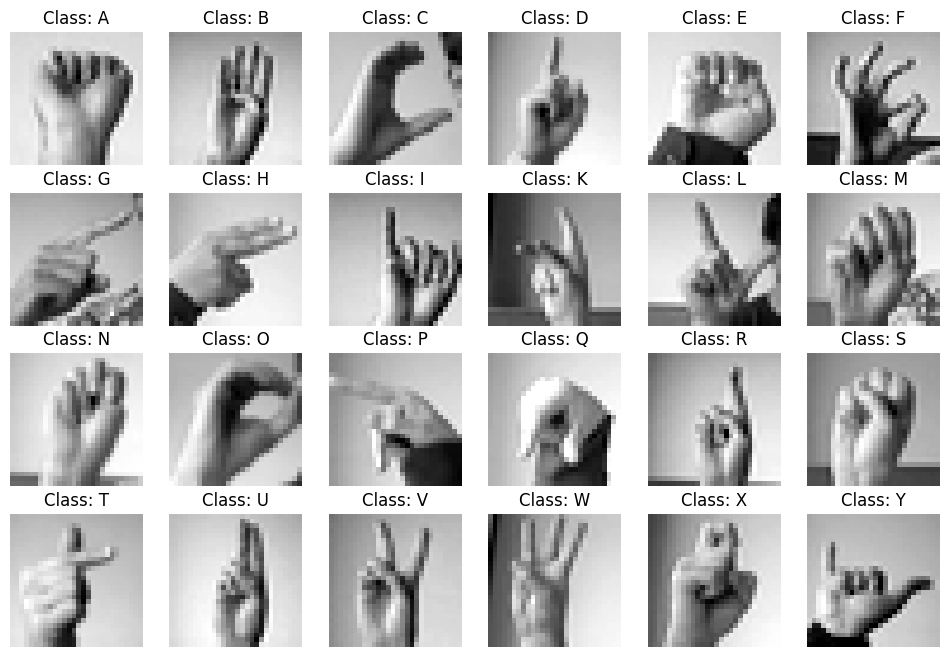

In [30]:
# TODO 2
label_to_name = {
    0: 'A', 1: 'B', 2: 'C', 3: 'D', 4: 'E', 5: 'F', 6: 'G', 7: 'H', 8: 'I', 9: 'K',
    10: 'L', 11: 'M', 12: 'N', 13: 'O', 14: 'P', 15: 'Q', 16: 'R', 17: 'S', 18: 'T',
    19: 'U', 20: 'V', 21: 'W', 22: 'X', 23: 'Y'
}

unique_labels_sorted = sorted(smnist_df['label'].unique())
num_classes = len(unique_labels_sorted)
fig, axes = plt.subplots(4, 6, figsize=(12, 8))
axes = axes.ravel()

for i, label in enumerate(unique_labels_sorted):
    sample = smnist_df[smnist_df['label'] == label].iloc[0]
    pixels = sample[1:].values
    image = pixels.reshape((28, 28))
    axes[i].imshow(image, cmap='gray')
    axes[i].set_title(f"Class: {label_to_name[label]}")
    axes[i].axis('off')

plt.show()

## Data Preprocessing

### Data Splitting

In [31]:
from sklearn.model_selection import train_test_split
def get_train_valid_test_data(
    X: np.ndarray,
    y: np.ndarray,
):
    """ Randomizes and then splits the data into train, validation, and test sets.

        Args:
            X: Data given as a 2D matrix

            y: Labels given as a vector
    """
    X_trn, X_tst, y_trn, y_tst = train_test_split(X, y, train_size=.8, random_state=42)
    X_trn, X_vld, y_trn, y_vld = train_test_split(X_trn, y_trn, train_size=.8, random_state=42)

    return X_trn, y_trn, X_vld, y_vld, X_tst, y_tst

### Putting it all together

#### TODO 3 (10 points): Preprocess Data

Complete the `get_preprocessed_data()` function for performing data preprocessing by satisfying the below requirements. The function should use the defined variables `X` and `y` for preprocessing and return a set of NumPy arrays: `X_trn`, `y_trn`, `X_vld`, `y_vld`, `X_tst`, and `y_tst`.

1. Convert the labels into a one-hot encoding using Sklearn's `OneHotEncoder` class or NumPy.
2. Split the data and labels into train, validation and test sets.
3. Standardize the training, validation, and testing data.
4. Add the bias to the first column of the training, validation, and testing data.

In [38]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
def get_preprocessed_data() -> Tuple[np.ndarray]:
    """ Gets preprocessed data for training, validation, and testing

        Returns:
            A tuple of NumPy arrays where indices 0-1
            contain the training data/targets, indices 2-3
            contain the validation data/targets, and 4-5
            contain the testing data/targets.
    """
    X_trn, y_trn, X_vld, y_vld, X_tst, y_tst = None, None, None, None, None, None
    # Drop the label column and store the features (pixel values) in X
    X = smnist_df.drop('label', axis=1).values
    y = smnist_df['label'].values

    # TODO 3.1 - 3.4
    encoder = OneHotEncoder(sparse_output=False)
    y_encoded = encoder.fit_transform(y.reshape(-1, 1))

    X_trn, y_trn, X_vld, y_vld, X_tst, y_tst = get_train_valid_test_data(X, y_encoded)

    scaler = StandardScaler()
    X_trn_scaled = scaler.fit_transform(X_trn)
    X_vld_scaled = scaler.transform(X_vld)
    X_tst_scaled = scaler.transform(X_tst)

    bias_trn = np.ones((X_trn_scaled.shape[0], 1))
    X_trn = np.hstack((bias_trn, X_trn_scaled))

    bias_vld = np.ones((X_vld_scaled.shape[0], 1))
    X_vld = np.hstack((bias_vld, X_vld_scaled))

    bias_tst = np.ones((X_tst_scaled.shape[0], 1))
    X_tst = np.hstack((bias_tst, X_tst_scaled))

    return X_trn, y_trn, X_vld, y_vld, X_tst, y_tst


In [39]:
def TEST_get_preprocessed_data():
    X_trn, y_trn, X_vld, y_vld, X_tst, y_tst = get_preprocessed_data()

    print(f"X_trn shape: {X_trn.shape}")
    print(f"y_trn shape: {y_trn.shape}")

    print(f"X_vld shape: {X_vld.shape}")
    print(f"y_vld shape: {y_vld.shape}")

    print(f"X_tst shape: {X_tst.shape}")
    print(f"y_tst shape: {y_tst.shape}")

    todo_check([
        # Split and one-hot tests
        ("isinstance(X_trn, np.ndarray)", "X_trn must be a NumPy array."),
        ("isinstance(X_vld, np.ndarray)", "X_vld must be a NumPy array."),
        ("isinstance(X_tst, np.ndarray)", "X_tst must be a NumPy array."),
        ("isinstance(y_trn, np.ndarray)", "y_trn must be a NumPy array."),
        ("isinstance(y_vld, np.ndarray)", "y_vld must be a NumPy array."),
        ("isinstance(y_tst, np.ndarray)", "y_tst must be a NumPy array."),
        ("X_trn.shape[1] == 785", "Each sample should have 784 features + 1 bias."),
        ("y_trn.shape[1] > 1", "y_trn should be one-hot encoded."),
        ("(X_trn[:, 0] == 1).all()", "Bias column (first col) in X_trn is not all ones."),
        ("(X_vld[:, 0] == 1).all()", "Bias column (first col) in X_vld is not all ones."),
        ("(X_tst[:, 0] == 1).all()", "Bias column (first col) in X_tst is not all ones."),
        # Label checks
        ("np.argmax(y_trn, axis=1).sum() == 205345", "y_trn had incorrect label encoding."),
        ("np.argmax(y_vld, axis=1).sum() == 51306", "y_vld had incorrect label encoding."),
        ("np.argmax(y_tst, axis=1).sum() == 64009", "y_tst had incorrect label encoding."),
        # Standardization
        ('np.isclose(X_trn[:, 1:].mean(axis=0).sum(), 0, rtol=0.01)', 'X_trn mean looks wrong.'),
        ('np.isclose(X_trn[:, 1:].std(axis=0).sum(), 784, rtol=0.01)', 'X_trn std looks wrong.'),
        ('np.isclose(X_vld[:, 1:].mean(axis=0).sum(), -6.7867, rtol=0.01)', 'X_vld mean looks wrong.'),
        ('np.isclose(X_vld[:, 1:].std(axis=0).sum(), 786.965, rtol=0.01)', 'X_vld std looks wrong.'),
        ('np.isclose(X_tst[:, 1:].mean(axis=0).sum(), -9.0727, rtol=0.01)', 'X_tst mean looks wrong.'),
        ('np.isclose(X_tst[:, 1:].std(axis=0).sum(), 787.318, rtol=0.01)', 'X_tst std looks wrong.'),
        # Bias Tests
        ("(X_trn[:, 0] == 1).all()", "The 1st column of `X_trn` does not seem to be the bias term (i.e., full of 1s)."),
        ("(X_vld[:, 0] == 1).all()", "The 1st column of `X_vld` does not seem to be the bias term (i.e., full of 1s)."),
        ("(X_tst[:, 0] == 1).all()", "The 1st column of `X_tst` does not seem to be the bias term (i.e., full of 1s)."),
    ], **locals())


TEST_get_preprocessed_data()

X_trn shape: (17571, 785)
y_trn shape: (17571, 24)
X_vld shape: (4393, 785)
y_vld shape: (4393, 24)
X_tst shape: (5491, 785)
y_tst shape: (5491, 24)
Your code PASSED all the code checks! 


## Metrics

In [40]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix
)

## Plots

The function `plot_decision_boundary()` aims to draw the decision boundary using a contour plot. This function will only work when your data has 2 features. Remember, having more than 2-3 features (i.e., higher dimensional features) means we have a much harder time visualizing the data.

In [41]:
def plot_decision_boundary(
    softreg: object,
    X: np.ndarray,
    y: np.ndarray,
    xlabel: str = '',
    ylabel: str = '',
    class_names: Dict = None
) -> None:
    """ Plots the decision boundry for data with 2 features.

        Warning:
            If you have more than 2 features (2D data) the decision boundry
            can not be plotted.

        Args:
            softreg: An instance of SoftmaxRegression class

            X: Data to be plotted

            y: Labels for corresponding data

            xlabel: X-axis label for plot

            ylabel: Y-axis label for plot

            class_names: Dictionary mapping labels to class names.
    """
    assert X.shape[-1] == 2, f"`X` must have 2 features not {X.shape[-1]}"

    if class_names is None:
        class_names = {}

    # Generate fake data to cover entire space of our input features X
    buffer = .5
    x_min, x_max = X[:, 0].min() - buffer, X[:, 0].max() + buffer
    y_min, y_max = X[:, 1].min() - buffer, X[:, 1].max() + buffer
    xx, yy = np.meshgrid(np.arange(x_min, x_max, .02),
                         np.arange(y_min, y_max, .02))
    fake_data = np.c_[xx.ravel(), yy.ravel()].reshape(-1,2)
    fake_data =  np.hstack([np.ones((len(fake_data), 1)), fake_data])
    # Make prediction
    y_hat = softreg.predict(fake_data)

    # Plot
    plt.contourf(xx, yy, y_hat.reshape(xx.shape))

    labels = np.unique(y)
    for l in labels:
        class_locs = np.where(y == l)[0]
        class_name = class_names.get(l, f'class {l}')
        plt.scatter(X[class_locs, 0], X[class_locs, 1], label=class_name)

    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.legend()
    plt.show()

The function `plot_confusion_matrix()`  plots the confusion matrix based on the passed labels and predictions.

In [42]:
def plot_confusion_matrix(
    y: np.ndarray,
    y_hat: np.ndarray,
    class_names: Dict[int, str] = None,
    figsize: Tuple = (10, 5)
) -> pd.DataFrame:
    """ Plots a pretty and labeld version of Sklerarn's confusion matrix

        Args:
            y: Ground truth labels given as a 1D vector

            y_hat: Predicted labels given as a 1D vector

            class_names: Dictionary mapping labels to class names.

                Example: {0: 'setosa', 1: 'versicolor', 2: 'virginica'}

            figsize: A tuple for setting the width and height of the plot.

        Returns:
            A confusion matrix casted as a DataFrame
    """
    y =  y.flatten() # reshape to make 1D vector for consistency
    y_hat = y_hat.flatten() # reshape to make 1D vector for consistency

    cfm = confusion_matrix(y_true=y, y_pred=y_hat)

    labels = np.sort(np.unique(y))
    if class_names is not None:
        classes = []
        for l in labels:
            class_name = class_names.get(l, l)
            classes.append(class_name)
        labels = classes

    columns, index = labels, labels
    fig, ax = plt.subplots(figsize=figsize)
    cfm_df = pd.DataFrame(cfm, index=index, columns=columns)
    sns.heatmap(cfm_df, annot=True, fmt='g', ax=ax)
    plt.show()
    return cfm_df

## Activation Functions

#### TODO 4 (10 points): Sigmoid
Complete the `sigmoid()` function by converting the below logistic sigmoid equation into code. The function should return an array with the same shape as the input `z`.

$$
\large\begin{align}
g(\zv) &= \frac{1}{1 + e^{-\zv}} \\
&= \frac{e^{\zv}}{1 + e^{\zv}}
\end{align}
$$

**Hint**
- The $\frac{e^{z}}{1 + e^{z}}$ version of the sigmoid function can help to prevent any overflow warnings. However, either version of the equation will pass this TODO.

In [45]:
def sigmoid(z: np.ndarray) -> np.ndarray:
    # TODO 4

    return np.exp(z) / (1 + np.exp(z))

x_values shape: (120, 1)
y_values shape: (120, 1)
Your code PASSED all the code checks! 


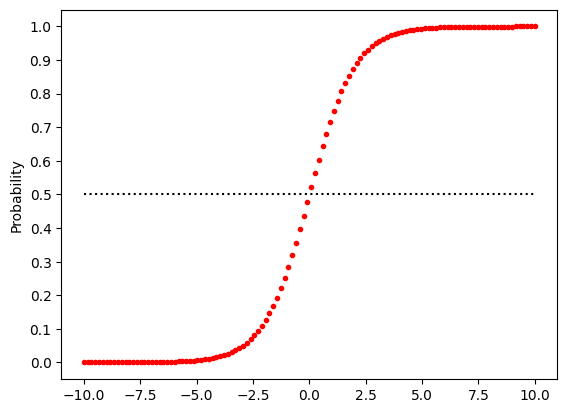

In [46]:
def TEST_sigmoid():
    x_values = np.linspace(-10, 10, 120).reshape(-1, 1)
    y_values = sigmoid(x_values)
    print(f"x_values shape: {x_values.shape}")
    print(f"y_values shape: {y_values.shape}")

    plt.plot(x_values, y_values, '.r')
    plt.hlines(y=.5, xmin=x_values.min(), xmax=x_values.max(),
               colors='black', linestyles='dotted')
    plt.yticks(np.arange(0, 1+.1, .1))
    plt.ylabel("Probability")

    todo_check([
        ("y_values.shape == (x_values.shape)", "sigmoid() output should be the same shape as the input."),
        ("np.all(np.isclose(y_values[:3].flatten(), np.array([4.53978687e-05, 5.37059651e-05, 6.35343990e-05]),rtol=.01))",
         "The returned sigmoid values were incorrect"),
        ('y_values.min() >= 0', "Minimum value was not 0."),
        ('y_values.max() <= 1', "Maximum value was not 1."),
    ], **locals())
TEST_sigmoid()

#### TODO 5 (10 points): Softmax
Complete the `softmax()` function by converting the below numerically stabilized softmax equation into code. The function should return an array with the same shape as the input `z`.

$$
\large\begin{align}
g(\zv)_i &= \frac{e^{z_i - z_{max}}}{\sum_{k=1}^K e^{z_k - z_{max}}}
\end{align}
$$

**Example**

Assuming the input `z` is a vector with the shape $(1, K)$ or a matrix with the shape $(N , K)$ where $N$ is the number of samples, $K$ is the number of classes, and $k$/$i$ are index locations. This version of the softmax works by subtracting the max for each row $ z_{max}$ to prevent under or overflow errors.  

**Hint**
- To compute $z_{max}$ you will need to take the max over all columns, such that each row has a single value. Think about which axis (0 or 1) corresponds to achieving this when computing the max of `z`.
- You can use `keepdims=True` argument for many NumPy functions to keep the output dimensions the same as the input.


In [47]:
def softmax(z: np.ndarray) -> np.ndarray:
    """ Computes the stablized version of the softmax

        Args:
            z: A vector or matrix of continuous values.

        Returns:
            A NumPy array with the same shape as the input.
    """
    # TODO 5
    z_max = np.max(z, axis=1, keepdims=True)
    numerator = np.exp(z - z_max)
    denominator = np.sum(np.exp(z - z_max), axis=1, keepdims=True)
    return numerator / denominator

In [48]:
def TEST_softmax_vector():
    rng = np.random.RandomState(0)
    z = rng.rand(1, 3)
    print(f"z shape: {z.shape}")
    print(f"z:\n{z}\n")

    probs = softmax(z)
    print(f"probs shape: {probs.shape}")
    print(f"probs:\n{probs}\n")

    todo_check([
        ("probs.shape == z.shape", f"Expected output shape for softmax() to be same as input {z.shape}"),
        ("np.isclose(probs.sum(), np.ones(len(z)))", "The softmax() rows did not sum to 1."),
        ("np.all(np.isclose(probs, np.array([[0.30898065, 0.36491138, 0.32610797]]), rtol=.01))",
         "softmax_probs has incorrect values"),
    ], **locals(), success_msg="+5 points")

TEST_softmax_vector()

z shape: (1, 3)
z:
[[0.5488135  0.71518937 0.60276338]]

probs shape: (1, 3)
probs:
[[0.30898065 0.36491138 0.32610797]]

Your code PASSED all the code checks! +5 points


In [49]:
def TEST_softmax_matrix():
    rng = np.random.RandomState(0)
    Z = rng.rand(5, 3)
    print(f"Z shape: {Z.shape}")
    print(f"Z:\n{Z}\n")

    probs = softmax(Z)
    print(f"probs shape: {probs.shape}")
    print(f"probs:\n{probs}\n")

    todo_check([
        ("probs.shape == Z.shape", f"Expected output shape for softmax() to be same as input {Z.shape}"),
        ("np.isclose(probs.sum(axis=1), np.ones(len(Z))).all()", "The softmax() rows did not sum to 1."),
        ("np.all(np.isclose(probs[:3, 0], np.array([0.30898065, 0.33421115, 0.23434743]), rtol=.01))",
         "softmax_matrix_probs has incorrecrt values"),
    ], **locals(), success_msg="+5 points")

TEST_softmax_matrix()

Z shape: (5, 3)
Z:
[[0.5488135  0.71518937 0.60276338]
 [0.54488318 0.4236548  0.64589411]
 [0.43758721 0.891773   0.96366276]
 [0.38344152 0.79172504 0.52889492]
 [0.56804456 0.92559664 0.07103606]]

probs shape: (5, 3)
probs:
[[0.30898065 0.36491138 0.32610797]
 [0.33421115 0.29605481 0.36973403]
 [0.23434743 0.36907156 0.396581  ]
 [0.27316453 0.41090326 0.31593222]
 [0.3291452  0.47062004 0.20023476]]

Your code PASSED all the code checks! +5 points


## Negative Log Likelihood (NLL)

#### TODO 6 (10 points): Generalized NLL

Complete the `nll_loss()` function by converting the below average NLL loss equation into code where $f(\xv; \Wm) = P(y \mid \xv; \Wm)$ are the predicted probabilities. This function should return a float.

$$
NLL(\Wm) = - \frac{1}{N}\sum_{n=1}^{N} {\yv_n} * \log[f(\xv_n;\Wm)]
$$



In [52]:
def nll_loss(y: np.ndarray, probs: np.ndarray) -> float:
    """ Computes the average generalized NLL Loss

        Args:
            y: The ground truth one-hot encoded labels
                given as matrix of shape (N, K).

            probs: The predicted probabilities for the
                corresponding labels given as a matrix
                of shape (N, K)
        Returns:
            A NLL loss given as a float.
    """
    # TODO 6
    num_samples = y.shape[0]
    epsilon = 1e-15
    y_pred_clipped = np.clip(probs, epsilon, 1 - epsilon)
    log_likelihoods = -np.sum(y * np.log(y_pred_clipped), axis=1)
    average_nll_loss = np.mean(log_likelihoods)
    return average_nll_loss

In [54]:
def TEST_nll_loss():
    y = np.array([
        [0., 1., 0.],
        [0., 0., 1.],
        [1., 0., 0.]
    ])
    y_hat_probs = np.array([
        [.1, .5, .4],
        [.1, .2, .7],
        [.3, .45, .25],
    ])
    avg_loss = nll_loss(y=y, probs=y_hat_probs)
    print(f"Averge NLL Loss: {avg_loss}")

    todo_check([
        ("np.isclose(avg_loss, 0.7512649, rtol=.01)", "Incorrect value for `nll_loss()` output")
    ], **locals())

TEST_nll_loss()

Averge NLL Loss: 0.7512649762748712
Your code PASSED all the code checks! 


## Coding Softmax Regression

#### TODO 7 (20 points): Softmax Regression
Compete the TODO by finishing the `SoftmaxRegression` class implementation.

**`fit()` TODOs**

Follow the below steps to implement the `fit()` method. Feel free to reuse code from prior homework.

1. Implement the `fit()` function according to the pseudocode provided below.
    1. Hint: Subscript $b$ corresponding to index samples at current batch, while $B$ corresponds to the size of the batch (i.e., number of samples in the batch).
    2. Hint: Initialize weights using `np.random.rand()`.
<center><img src="https://live.staticflickr.com/65535/54132218806_2e855aa63c_c.jpg" width="800" height="538" alt="softmax-regression"/></center>
<br><br>
2. Add lines 11-15 which will be used to measure and store the training/validation NLL loss for the current epoch. Learning curves will not plot without this!

```python
trn_probs = softmax(X @ self.W)
trn_loss = nll_loss(y, trn_probs)
self.trn_loss.append(trn_loss)

if X_vld is not None and y_vld is not None:
    vld_probs = softmax(X_vld @ self.W)
    vld_loss = nll_loss(y_vld, vld_probs)
    self.vld_loss.append(vld_loss)
```

**`predict()` TODOs**

Follow the below steps to implement the `predict()` method. Feel free to reuse code from prior homework.

2. Compute the predictions by implementing the below equation. Return the predictions as a 2D column vector.
  
$$
 \hat{\yv}  = \arg \max(\Xm \Wm)
$$

**Hint**
- You do not need to reimplement any equations in the code that we have already implemented (e.g., NLL loss). Simply reuse those functions.

In [55]:
def get_batches(
    data_len: int,
    batch_size: int = 32,
) -> List[np.ndarray]:
    """ Generates mini-batches based on the data indexes

        Args:
            data_len: Length of the data or number of data samples
                in the data. This is used to generate the indices of
                the data.

            batch_size: Size of each mini-batch where the last mini-batch
                might be smaller than the rest if the batch_size does not
                evenly divide the data length.

        Returns:
            A list of NumPy array's holding the indices of batches
    """
    indices = np.arange(data_len)
    np.random.shuffle(indices)
    batches = [indices[i:i+batch_size] for i in range(0, data_len, batch_size)]

    return batches

In [58]:
class SoftmaxRegression():
    """ Performs softmax regression using gradient descent

        Attributes:

            alpha: learning rate or step size.

            batch_size: Size of mini-batches for mini-batch gradient
                descent.

            epochs: Number of epochs to run for mini-batch
                gradient descent.

            seed: Seed to be used for NumPy's RandomState class
                or universal seed np.random.seed() function.

            W: Matrix of weights with shape (M, K)

            trn_loss: Stores the training loss for each epoch.

            vld_loss: Stores the validation loss for each epoch.
    """
    def __init__(
        self,
        alpha: float,
        batch_size: int,
        epochs: int = 1,
        seed: int = 0,
    ):

        self.alpha = alpha
        self.batch_size = batch_size
        self.epochs = epochs
        self.seed = seed

        self.W = None
        self.trn_loss = None
        self.vld_loss = None

    def fit(
         self,
         X: np.ndarray,
         y: np.ndarray,
         X_vld: np.ndarray=None,
         y_vld: np.ndarray=None
     ) -> object:
        """ Trains softmax regressio using SGD

            Args:
                X: Training data given as a 2D matrix

                y: Training labels given as a 2D column vector

                X_vld: Validation data given as a 2D matrix. Used
                    to compute the validation accuracy for each epoch.

                y_vld: Validation labels given as a 2D matrix. Used
                    to compute the validation accuracy for each epoch.

            Returns:
                The class's own object reference.
        """
        # Set seed for reproducibility
        np.random.seed(self.seed)
        # Track training/validation loss
        self.trn_loss = []
        self.vld_loss = []

        # TODO 7.1
        num_features = X.shape[1]
        num_classes = y.shape[1]
        self.W = np.random.rand(num_features, num_classes)

        for e in range(self.epochs):
            batches = get_batches(len(X), batch_size=self.batch_size)
            for batch_indices in batches:
                X_b = X[batch_indices]
                y_b = y[batch_indices]
                Z_b = X_b @ self.W
                Y_probs_b = softmax(Z_b)
                self.W = self.W - (self.alpha / len(X_b)) * (X_b.T @ (Y_probs_b - y_b))

            trn_probs = softmax(X @ self.W)
            trn_loss = nll_loss(y, trn_probs)
            self.trn_loss.append(trn_loss)

            if X_vld is not None and y_vld is not None:
                vld_probs = softmax(X_vld @ self.W)
                vld_loss = nll_loss(y_vld, vld_probs)
                self.vld_loss.append(vld_loss)

        return self

    def predict(self, X: np.ndarray) -> np.ndarray:
        """ Make predictions using learned weights

            Args:
                X: Testing data given as a 2D matrix

            Returns:
                A 2D column vector of predictions for each data sample in X
        """
        # TODO 7.2
        Z = X @ self.W
        y_hat = np.argmax(Z, axis=1).reshape(-1, 1)
        return y_hat

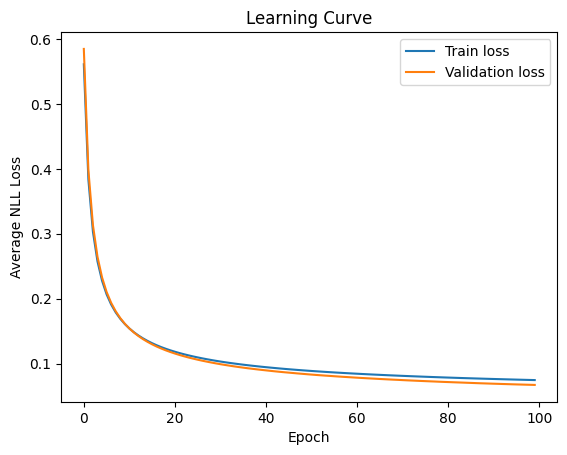

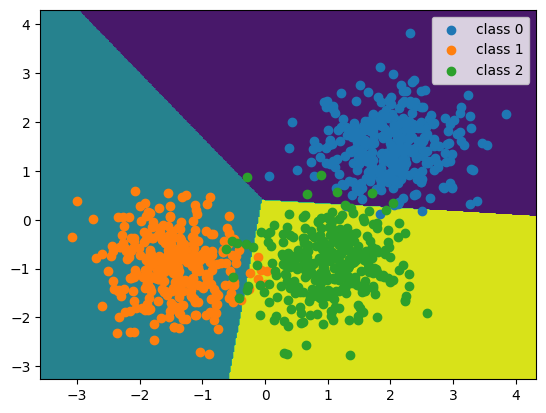

Validation Accuracy: 0.98
Weights: [-0.29371437  0.95801035  1.39295238  2.00800771 -2.78172088  1.68438482
  3.14386291 -0.48646303 -1.1320251 ]
Your code PASSED all the code checks! 


In [59]:
def TEST_SoftmaxRegression():
    from sklearn.datasets import make_blobs
    X, y = make_blobs(
        n_samples=1000,
        random_state=42,
        centers=[[2, 1.5], [-1.5, -1], [1, -1]],
        cluster_std=0.6
    )
    n_values = np.max(y) + 1
    y = np.eye(n_values)[y.flatten()]
    X = np.hstack([np.ones([len(X), 1]), X])
    X_trn, X_vld, y_trn, y_vld = train_test_split(X, y, random_state=42)

    softreg = SoftmaxRegression(epochs=100, batch_size=64, alpha=.1, seed=42)
    softreg.fit(X_trn, y_trn, X_vld=X_vld, y_vld=y_vld)
    y_hat = softreg.predict(X_vld)

    plt.plot(softreg.trn_loss, label='Train loss')
    plt.plot(softreg.vld_loss, label='Validation loss')
    plt.title("Learning Curve")
    plt.ylabel("Average NLL Loss")
    plt.xlabel("Epoch")
    plt.legend()
    plt.show()

    plot_decision_boundary(softreg, X[:, 1:], np.argmax(y, axis=1))

    acc = accuracy_score(np.argmax(y_vld, axis=1), y_hat)
    print(f"Validation Accuracy: {acc}")
    print(f"Weights: {softreg.W.flatten()}")

    todo_check([
        ("len(softreg.trn_loss) == 100", "Expected 100 training evaluations for `self.trn_loss`. Make sure you added code for tracking the training accuracy and added the convergence check."),
        ("len(softreg.vld_loss) == 100", "Expected 100 validation evaluations for `self.vld_loss`. Make sure you added code for tracking the validation accuracy and added the convergence check."),
        ("acc == .98", "Incorrect accuracy value"),
        ("np.all(np.isclose(softreg.W.flatten()[:3], np.array([ -0.29371,  0.95801,  1.39295]), rtol=.01))", "Incorrect weight values.")
    ], **locals())

TEST_SoftmaxRegression()

## Sign MNIST With Softmax Regression

#### TODO 8 (25 points)
To complete this TODO by performing multi-classification on the Sign MNIST dataset.

- Data Loading
    - Load the training, validation, and test datasets.
- Training
    - Initialize an instance of `SoftmaxRegression()` and fit it on the training data.
    - Compute and display the training accuracy.
    - Plot the learning curve, which should include the training and validation losses for each epoch.
    - Plot the confusion matrix for the training data.
- Validation
    - Compute and display the validation accuracy.
    - Plot the confusion matrix for the validation data.
- Testing
    - Compute and display the testing accuracy.
    - Plot the confusion matrix for the testing data.
  
**Hints**

- To compute the accuracy and confusion matrix, you will need to undo the one-hot encodings. You can do so by taking the $\arg \max$ over the columns.
- When plotting the confusion matrix, pass `label2name` to `class_names` to plot the actual class names.

#### Training

Training Accuracy: 1.0


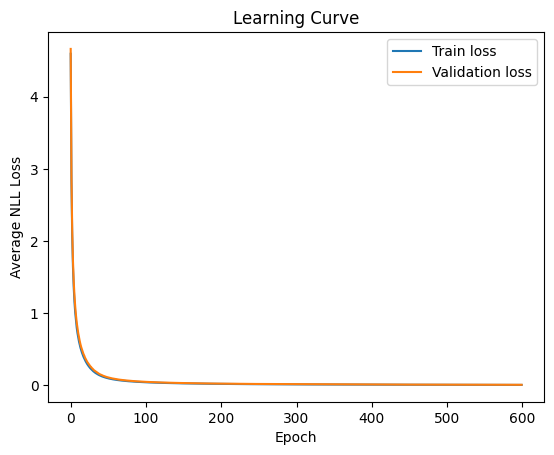

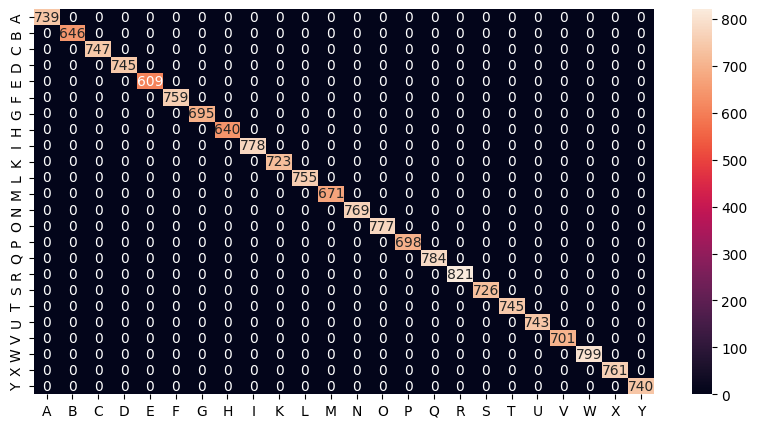

,A,B,C,D,E,F,G,H,I,K,...,P,Q,R,S,T,U,V,W,X,Y
A,739,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
B,0,646,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
C,0,0,747,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
D,0,0,0,745,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
E,0,0,0,0,609,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
F,0,0,0,0,0,759,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
G,0,0,0,0,0,0,695,0,0,0,...,0,0,0,0,0,0,0,0,0,0
H,0,0,0,0,0,0,0,640,0,0,...,0,0,0,0,0,0,0,0,0,0
I,0,0,0,0,0,0,0,0,778,0,...,0,0,0,0,0,0,0,0,0,0
K,0,0,0,0,0,0,0,0,0,723,...,0,0,0,0,0,0,0,0,0,0


In [108]:
# TODO 8: Training Code
X_trn, y_trn_encoded, X_vld, y_vld_encoded, X_tst, y_tst_encoded = get_preprocessed_data()

alpha = 0.01
batch_size = 64
epochs = 600
model = SoftmaxRegression(alpha=alpha, batch_size=batch_size, epochs=epochs, seed=42)
model.fit(X_trn, y_trn_encoded, X_vld, y_vld_encoded)

trn_probs = softmax(X_trn @ model.W)
trn_preds = np.argmax(trn_probs, axis=1)
trn_accuracy = accuracy_score(np.argmax(y_trn_encoded, axis=1), trn_preds)
print(f"Training Accuracy: {trn_accuracy}")

plt.plot(model.trn_loss, label='Train loss')
plt.plot(model.vld_loss, label='Validation loss')
plt.title("Learning Curve")
plt.ylabel("Average NLL Loss")
plt.xlabel("Epoch")
plt.legend()
plt.show()

plot_confusion_matrix(np.argmax(y_trn_encoded, axis=1), trn_preds, class_names=label2name)

#### Validation

Validation Accuracy: 0.9997723651263374


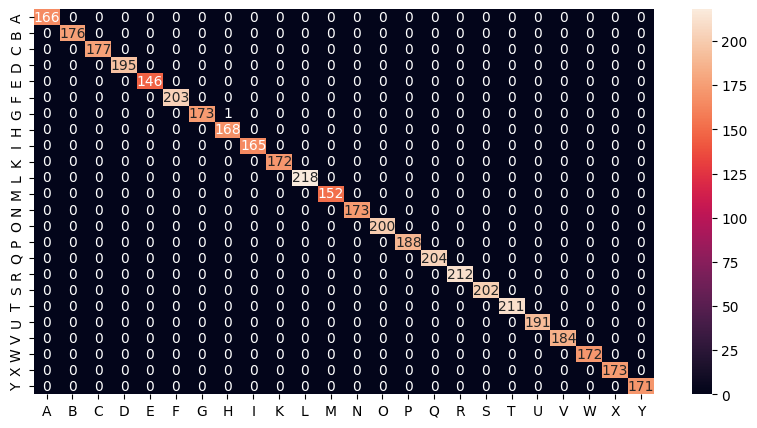

,A,B,C,D,E,F,G,H,I,K,...,P,Q,R,S,T,U,V,W,X,Y
A,166,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
B,0,176,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
C,0,0,177,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
D,0,0,0,195,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
E,0,0,0,0,146,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
F,0,0,0,0,0,203,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
G,0,0,0,0,0,0,173,1,0,0,...,0,0,0,0,0,0,0,0,0,0
H,0,0,0,0,0,0,0,168,0,0,...,0,0,0,0,0,0,0,0,0,0
I,0,0,0,0,0,0,0,0,165,0,...,0,0,0,0,0,0,0,0,0,0
K,0,0,0,0,0,0,0,0,0,172,...,0,0,0,0,0,0,0,0,0,0


In [112]:
# TODO 8: Validation Code
vld_probs = softmax(X_vld @ model.W)
vld_preds = np.argmax(vld_probs, axis=1)
vld_accuracy = accuracy_score(np.argmax(y_vld_encoded, axis=1), vld_preds)
print(f"Validation Accuracy: {vld_accuracy}")

plot_confusion_matrix(np.argmax(y_vld_encoded, axis=1), vld_preds, class_names=label2name)


#### Testing

Testing Accuracy: 0.9994536514296121


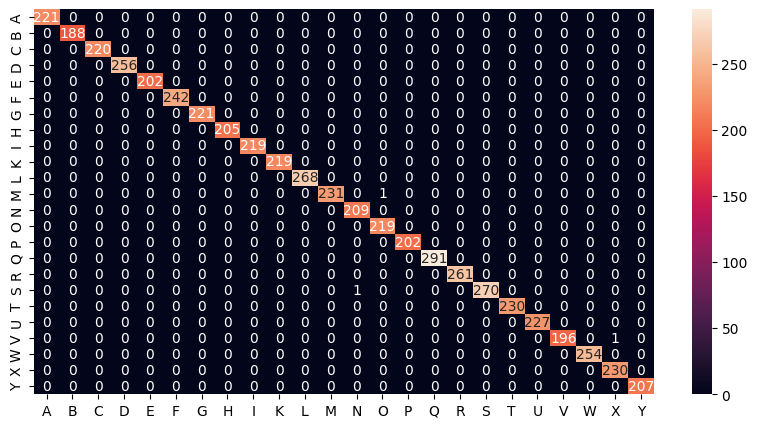

,A,B,C,D,E,F,G,H,I,K,...,P,Q,R,S,T,U,V,W,X,Y
A,221,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
B,0,188,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
C,0,0,220,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
D,0,0,0,256,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
E,0,0,0,0,202,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
F,0,0,0,0,0,242,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
G,0,0,0,0,0,0,221,0,0,0,...,0,0,0,0,0,0,0,0,0,0
H,0,0,0,0,0,0,0,205,0,0,...,0,0,0,0,0,0,0,0,0,0
I,0,0,0,0,0,0,0,0,219,0,...,0,0,0,0,0,0,0,0,0,0
K,0,0,0,0,0,0,0,0,0,219,...,0,0,0,0,0,0,0,0,0,0


In [111]:
# TODO 8: Testing Code
tst_probs = softmax(X_tst @ model.W)
tst_preds = np.argmax(tst_probs, axis=1)
tst_accuracy = accuracy_score(np.argmax(y_tst_encoded, axis=1), tst_preds)
print(f"Testing Accuracy: {tst_accuracy}")

plot_confusion_matrix(np.argmax(y_tst_encoded, axis=1), tst_preds, class_names=label2name) # Pass correct args

## Extra Credit TODO (See Canvas for Points)

For this extra credit, you will explore the effect of dimensionality reduction using Principal Component Analysis (PCA) on the performance of a logistic regression classifier. At a high level, PCA is used to reduce the number of features. Thus, the goal will be to take out 784 features and transform them to be more "informative" so we can use fewer features while still maintaining a similar or better classification accuracy.

1. Finish the `get_preprocessed_PCA_data()` below by copying your solution code from the previously defined `get_preprocessed_data()` function. Apply PCA using Sklearn's PCA class after standardization but before adding the bias. Do so by first fitting and transforming the training data and then only transforming the validation and testing data.
    1. Import PCA from `sklearn.decomposition`. To learn more about PCA see the [docs](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html).
    2. Choose a fixed number of components (e.g., 50). These components represent the number of new features to be used (the maximum is 784, as there are 784 features in the original data). Try experimenting with different numbers of components to see how they affect classification accuracy.
    3. Use the `fit_transform()` and `transform()` PCA methods.
2. Training
    1. Initialize an instance of `SoftmaxRegression()` and fit it on the PCA training data returned from calling the `get_preprocessed_PCA_data()` function.
    2. Compute and display the training accuracy.
    3. Plot the learning curve, which should include the training and validation losses for each epoch.
    4. Plot the confusion matrix for the training data.
3. Validation
    1. Compute and display the validation accuracy.
    2. Plot the confusion matrix for the validation data.
4. Testing
    1. Compute and display the testing accuracy.
    2. Plot the confusion matrix for the testing data.

### PCA Preprocessing

In [91]:
from sklearn.decomposition import PCA

def get_preprocessed_PCA_data() -> Tuple[np.ndarray]:
    """ Gets PCA preprocessed data for training, validation, and testing

        Returns:
            A tuple of NumPy arrays where indices 0-1
            contain the training data/targets, indices 2-3
            contain the validation data/targets, and 4-5
            contain the testing data/targets.
    """
    X_trn, y_trn, X_vld, y_vld, X_tst, y_tst = None, None, None, None, None, None
    # Drop the label column and store the features (pixel values) in X
    X = smnist_df.drop('label', axis=1).values
    y = smnist_df['label'].values

    # Extra credit: Paste solution code from get_preprocessed_data() here
    # and add PCA code right after standardization but before adding the bias.
    encoder = OneHotEncoder(sparse_output=False)
    y_encoded = encoder.fit_transform(y.reshape(-1, 1))
    X_trn, y_trn, X_vld, y_vld, X_tst, y_tst = get_train_valid_test_data(X, y_encoded)
    scaler = StandardScaler()
    X_trn_scaled = scaler.fit_transform(X_trn)
    X_vld_scaled = scaler.transform(X_vld)
    X_tst_scaled = scaler.transform(X_tst)

    pca = PCA(n_components=100)
    X_trn_pca = pca.fit_transform(X_trn_scaled)
    X_vld_pca = pca.transform(X_vld_scaled)
    X_tst_pca = pca.transform(X_tst_scaled)

    bias_trn = np.ones((X_trn_pca.shape[0], 1))
    X_trn = np.hstack((bias_trn, X_trn_pca))
    bias_vld = np.ones((X_vld_pca.shape[0], 1))
    X_vld = np.hstack((bias_vld, X_vld_pca))
    bias_tst = np.ones((X_tst_pca.shape[0], 1))
    X_tst = np.hstack((bias_tst, X_tst_pca))

    return X_trn, y_trn, X_vld, y_vld, X_tst, y_tst

In [92]:
X_trn, y_trn, X_vld, y_vld, X_tst, y_tst = get_preprocessed_PCA_data()

print(f"X_trn shape: {X_trn.shape}")
print(f"y_trn shape: {y_trn.shape}")

print(f"X_vld shape: {X_vld.shape}")
print(f"y_vld shape: {y_vld.shape}")

print(f"X_tst shape: {X_tst.shape}")
print(f"y_tst shape: {y_tst.shape}")

X_trn shape: (17571, 101)
y_trn shape: (17571, 24)
X_vld shape: (4393, 101)
y_vld shape: (4393, 24)
X_tst shape: (5491, 101)
y_tst shape: (5491, 24)


### Training

Training Accuracy: 1.0


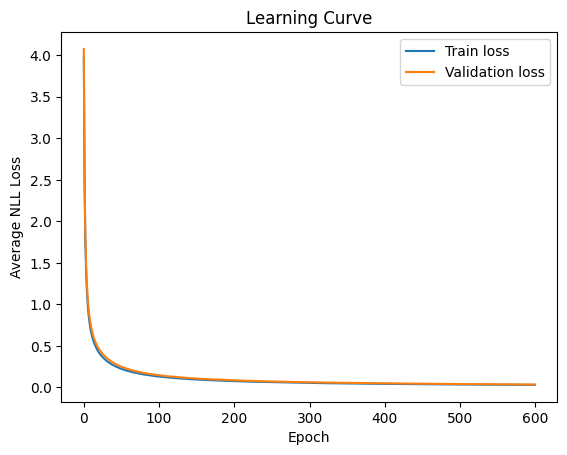

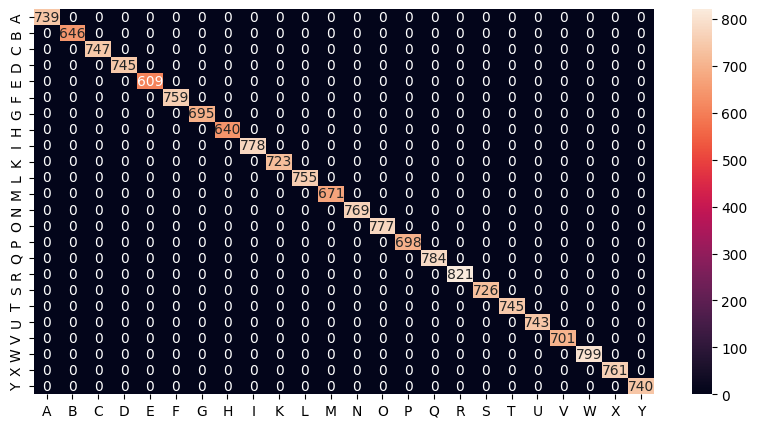

,A,B,C,D,E,F,G,H,I,K,...,P,Q,R,S,T,U,V,W,X,Y
A,739,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
B,0,646,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
C,0,0,747,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
D,0,0,0,745,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
E,0,0,0,0,609,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
F,0,0,0,0,0,759,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
G,0,0,0,0,0,0,695,0,0,0,...,0,0,0,0,0,0,0,0,0,0
H,0,0,0,0,0,0,0,640,0,0,...,0,0,0,0,0,0,0,0,0,0
I,0,0,0,0,0,0,0,0,778,0,...,0,0,0,0,0,0,0,0,0,0
K,0,0,0,0,0,0,0,0,0,723,...,0,0,0,0,0,0,0,0,0,0


In [103]:
# Extra Credit: Training Code
X_trn_pca, y_trn_pca, X_vld_pca, y_vld_pca, X_tst_pca, y_tst_pca = get_preprocessed_PCA_data()

alpha = 0.01
batch_size = 64
epochs = 600
model_pca = SoftmaxRegression(alpha=alpha, batch_size=batch_size, epochs=epochs, seed=42)
model_pca.fit(X_trn_pca, y_trn_pca, X_vld_pca, y_vld_pca)

trn_probs_pca = softmax(X_trn_pca @ model_pca.W)
trn_preds_pca = np.argmax(trn_probs_pca, axis=1)
trn_accuracy_pca = accuracy_score(np.argmax(y_trn_pca, axis=1), trn_preds_pca)
print(f"Training Accuracy: {trn_accuracy_pca}")

plt.plot(model_pca.trn_loss, label='Train loss')
plt.plot(model_pca.vld_loss, label='Validation loss')
plt.title("Learning Curve")
plt.ylabel("Average NLL Loss")
plt.xlabel("Epoch")
plt.legend()
plt.show()

plot_confusion_matrix(np.argmax(y_trn_pca, axis=1), trn_preds_pca, class_names=label2name)


### Validation

Validation Accuracy: 0.999317095379012


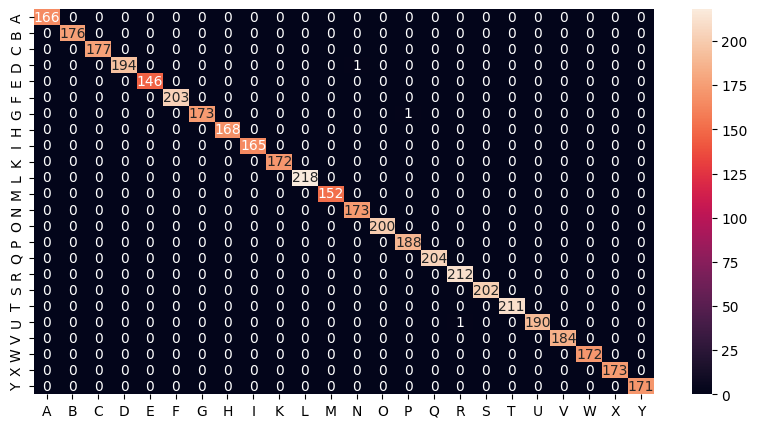

,A,B,C,D,E,F,G,H,I,K,...,P,Q,R,S,T,U,V,W,X,Y
A,166,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
B,0,176,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
C,0,0,177,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
D,0,0,0,194,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
E,0,0,0,0,146,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
F,0,0,0,0,0,203,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
G,0,0,0,0,0,0,173,0,0,0,...,1,0,0,0,0,0,0,0,0,0
H,0,0,0,0,0,0,0,168,0,0,...,0,0,0,0,0,0,0,0,0,0
I,0,0,0,0,0,0,0,0,165,0,...,0,0,0,0,0,0,0,0,0,0
K,0,0,0,0,0,0,0,0,0,172,...,0,0,0,0,0,0,0,0,0,0


In [107]:
# Extra Credit: Validation Code
vld_probs_pca = softmax(X_vld_pca @ model_pca.W)
vld_preds_pca = np.argmax(vld_probs_pca, axis=1)
vld_accuracy_pca = accuracy_score(np.argmax(y_vld_pca, axis=1), vld_preds_pca)
print(f"Validation Accuracy: {vld_accuracy_pca}")
plot_confusion_matrix(np.argmax(y_vld_pca, axis=1), vld_preds_pca, class_names=label2name)

### Testing

Testing Accuracy: 0.9994536514296121


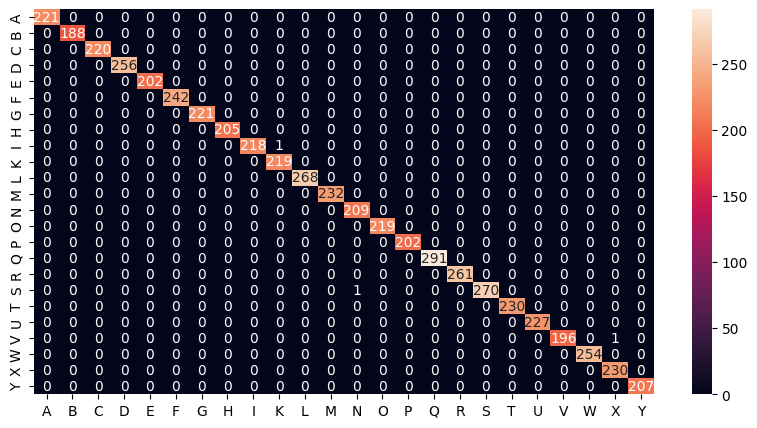

,A,B,C,D,E,F,G,H,I,K,...,P,Q,R,S,T,U,V,W,X,Y
A,221,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
B,0,188,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
C,0,0,220,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
D,0,0,0,256,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
E,0,0,0,0,202,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
F,0,0,0,0,0,242,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
G,0,0,0,0,0,0,221,0,0,0,...,0,0,0,0,0,0,0,0,0,0
H,0,0,0,0,0,0,0,205,0,0,...,0,0,0,0,0,0,0,0,0,0
I,0,0,0,0,0,0,0,0,218,1,...,0,0,0,0,0,0,0,0,0,0
K,0,0,0,0,0,0,0,0,0,219,...,0,0,0,0,0,0,0,0,0,0


In [106]:
# Extra Credit: Testing Code
tst_probs_pca = softmax(X_tst_pca @ model_pca.W)
tst_preds_pca = np.argmax(tst_probs_pca, axis=1)
tst_accuracy_pca = accuracy_score(np.argmax(y_tst_pca, axis=1), tst_preds_pca)
print(f"Testing Accuracy: {tst_accuracy_pca}")
plot_confusion_matrix(np.argmax(y_tst_pca, axis=1), tst_preds_pca, class_names=label2name)